# Wind direction on a swell boundary, against SWAN

Notebook 05 asked whether `waveray`'s wind input is the right size. This one asks
whether it points the right way.

The Komen et al. (1984) growth rate carries a directional cutoff,

$$B = \max\!\left[0,\; 0.25\,\frac{\rho_a}{\rho_w}\left(\frac{28 u_*}{c}\cos(\theta-\theta_w) - 1\right)\right]\sigma ,$$

so a wave component running *into* the wind gets no growth at all, and one running
across it grows at a reduced rate. That cutoff is the whole directional physics of
the input term, and it is cheap to get wrong in a way integrated wave height hides —
a wind sea placed in the wrong bins still raises $H_s$.

So the same plane beach and the same 2 m / 10 s swell from the west are run under a
12 m/s wind from four directions, against full-physics SWAN:

| wind from | relative to the swell | what it probes |
|---|---|---|
| 270° | dead onshore, aligned | growth at $\cos = 1$ — the notebook-05 case |
| 225° | 45° oblique | the $\cos(\theta-\theta_w)$ weighting |
| 180° | alongshore, 90° across | the cutoff's edge: $\cos = 0$ |
| 90° | offshore, opposed | the cutoff itself: no growth on the swell |

These back `test_wind_direction_on_swell` and `test_offshore_wind_is_the_cutoff_working`
in `tests/test_validation_swan.py`. The notebook plots what those tests assert
numerically: the domain they run in, the height profiles, and — the part a scalar
test cannot show — the **directional spectra at the target**.

SWAN runs with full physics throughout (quadruplets and whitecapping on), so every
disagreement below is a *surrogate error*: the cost of using waveray in place of a
real SWAN run, not a claim that either model is wrong.

In [1]:
%matplotlib inline
import sys
import tempfile
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, LogNorm

sys.path.insert(0, "..")  # repo root (src layout, waveray is installed editable)
sys.path.insert(0, "../tests")  # validation.cases, validation.swan

from validation.cases import plane_beach_case, wind_on_swell_case
from validation.swan import read_spectra, swan_image_available

from waveray.breaking import spectral_moment

assert swan_image_available(pull=False), "docker pull delftwaves/swan:latest first"

# SWAN scratch (bathymetry, boundary spectra, PRINT/table/spectral output) goes
# to a temp dir, never into the repository.
WORKDIR = Path(tempfile.mkdtemp(prefix="waveray_swan_winddir_"))

# Validated palette (dataviz reference instance, light mode) -- matches notebook 05.
SURFACE = "#fcfcfb"
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
BLUE, AQUA, YELLOW, ORANGE = "#2a78d6", "#1baf7a", "#eda100", "#eb6834"

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.size": 10,
        "axes.edgecolor": "#d5d4cf",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "600",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "grid.color": "#ecebe6",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "lines.solid_capstyle": "round",
    }
)

# SWAN = orange, waveray(+wind) = blue, waveray(no wind) = aqua, throughout.
COLOR_SWAN, COLOR_WRAY, COLOR_NOWIND = ORANGE, BLUE, AQUA
# Sequential single hue (light -> dark) for the spectral density panels.
CMAP_SPEC = LinearSegmentedColormap.from_list(
    "wr_blue", ["#f5f8fd", "#c2d8f2", "#7fb0e6", "#2a78d6", "#14406f"]
)
CMAP_DEPTH = LinearSegmentedColormap.from_list("wr_depth", ["#e8f0fa", "#2a78d6", "#0e2f57"])

U10 = 12.0
WIND_DIRS = [
    (270.0, "onshore, aligned"),
    (225.0, "oblique 45"),
    (180.0, "alongshore"),
    (90.0, "offshore, opposed"),
]
TARGET_DEPTHS = [20.0, 12.0, 6.0]
FOCUS = 1  # the 12 m target -- the "location of interest" for the spectra below


def blows_toward(deg):
    """Unit vector a nautical *coming-from* direction blows toward, as (east, north)."""
    th = np.deg2rad(deg)
    return -np.sin(th), -np.cos(th)


def hs_of(efth, freqs, dirs):
    """Hs from a single (nfreq, ndir) spectrum, the package's own quadrature."""
    return 4.0 * np.sqrt(max(spectral_moment(np.asarray(efth)[None], freqs, dirs, n=0)[0], 0.0))


def swan_efth(ds, target):
    """One target's (freq, dir) spectrum from a wavespectra dataset, m2/Hz/deg.

    Selected by coordinate rather than by position: wavespectra reshapes SWAN's
    output points onto a lat/lon grid when they happen to form one (these three
    share a y, so they arrive as lat=1, lon=3) and leaves them as a ``site``
    dim otherwise, so positional indexing would only work by accident.
    """
    tx, ty = target
    da = ds.efth
    if "time" in da.dims:
        da = da.isel(time=0)
    if "site" in da.dims:
        d2 = (da.lon.values - tx) ** 2 + (da.lat.values - ty) ** 2
        da = da.isel(site=int(np.argmin(d2)))
    else:
        da = da.sel(lon=tx, lat=ty, method="nearest")
    return da.transpose("freq", "dir")

## The domain

`wind_on_swell_case()` is `plane_beach_case()` with a uniform wind added. The seabed
falls linearly from 30 m at the offshore boundary to 4 m over 15 km and is uniform
alongshore; the domain is deliberately far wider (80 km) than it is long, so the
arrival cone of every target is fully supplied by the offshore boundary and neither
model sees a lateral energy deficit. There is no shoreline in the grid — it stops
at 4 m — because depth-induced breaking is switched off in both models here
(waveray applies it at the target as a post-step, so leaving it out of both keeps
the comparison to propagation plus wind).

Targets sit at the 20 m, 12 m and 6 m isobaths. The wind blows over whatever fetch
lies upwind of each target *inside* the domain, which is the point of the offshore
case: SWAN has 0–15 km of fetch to build an offshore-going sea over, and that sea
counts toward $H_s$ at the target even though it is travelling the wrong way.

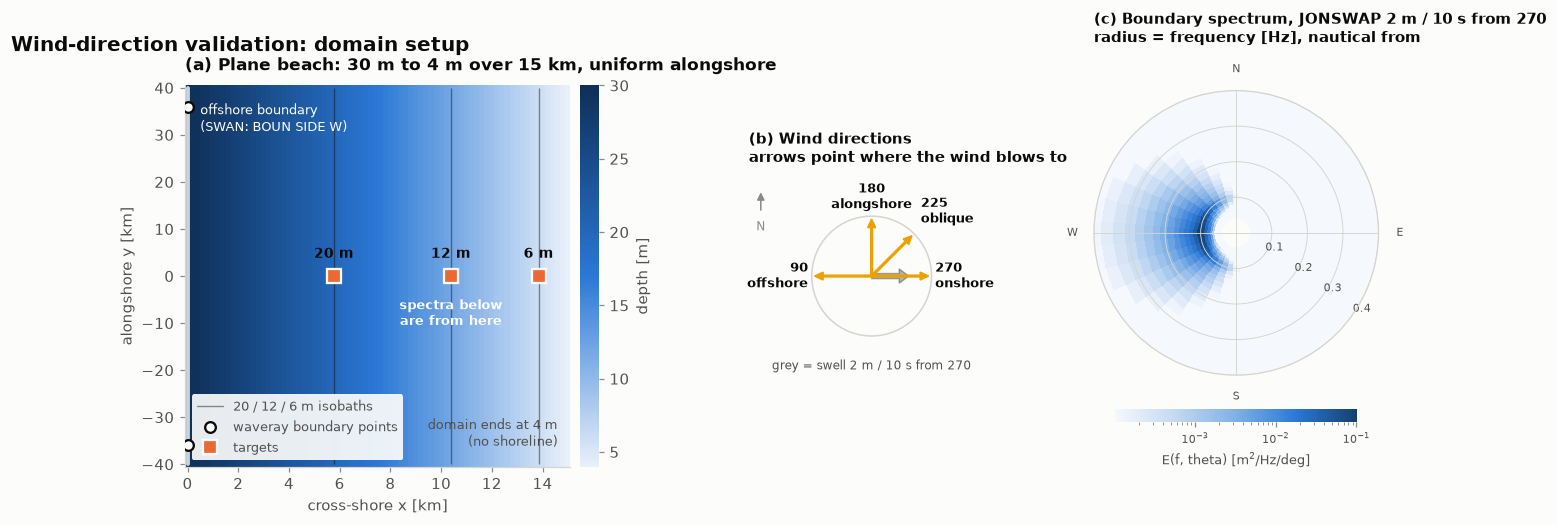

,target,x [km],y [km],depth [m],fetch to offshore boundary [km]
0,20 m,5.77,0.0,20.0,5.77
1,12 m (focus),10.38,0.0,12.0,10.38
2,6 m,13.85,0.0,6.0,13.85


In [2]:
case_ref = plane_beach_case(name="wd_ref", dpm=270.0)
gx, gy, gd = case_ref.x, case_ref.y, case_ref.depth
targets = np.asarray(case_ref.targets)

fig = plt.figure(figsize=(14.0, 4.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.55, 0.82, 0.95], wspace=0.30)

# -- (a) bathymetry, isobaths, targets, boundary --------------------------------
ax = fig.add_subplot(gs[0, 0])
mesh = ax.pcolormesh(gx / 1e3, gy / 1e3, gd, cmap=CMAP_DEPTH, shading="nearest", zorder=1)
cb = fig.colorbar(mesh, ax=ax, pad=0.02)
cb.set_label("depth [m]", color=INK_2)
cb.outline.set_visible(False)

ax.contour(
    gx / 1e3,
    gy / 1e3,
    gd,
    levels=TARGET_DEPTHS[::-1],
    colors=[INK],
    linewidths=0.9,
    alpha=0.45,
    zorder=4,
)
ax.plot([], [], "-", color=INK, lw=0.9, alpha=0.45, label="20 / 12 / 6 m isobaths")

# waveray's boundary points, and the SWAN boundary side they stand in for
ax.plot([0, 0], [gy[0] / 1e3, gy[-1] / 1e3], "-", color=SURFACE, lw=2.5, alpha=0.8, zorder=5)
ax.plot(
    case_ref.boundary_xy[:, 0] / 1e3,
    case_ref.boundary_xy[:, 1] / 1e3,
    "o",
    color=SURFACE,
    ms=7,
    mec=INK,
    mew=1.5,
    zorder=6,
    label="waveray boundary points",
)
ax.text(
    0.5,
    gy[-1] / 1e3 - 3,
    "offshore boundary\n(SWAN: BOUN SIDE W)",
    color=SURFACE,
    fontsize=8.5,
    va="top",
    zorder=7,
)
ax.text(
    14.6,
    gy[0] / 1e3 + 3,
    "domain ends at 4 m\n(no shoreline)",
    color=INK_2,
    fontsize=8.5,
    ha="right",
    va="bottom",
)

ax.plot(
    targets[:, 0] / 1e3,
    targets[:, 1] / 1e3,
    "s",
    color=ORANGE,
    ms=9,
    mec=SURFACE,
    mew=1.5,
    zorder=7,
    label="targets",
)
for (tx, _ty), d in zip(targets, TARGET_DEPTHS, strict=True):
    ax.annotate(
        f"{d:.0f} m",
        (tx / 1e3, 0.0),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        color=INK,
        fontsize=9,
        fontweight="600",
        zorder=7,
    )
ax.annotate(
    "spectra below\nare from here",
    (targets[FOCUS, 0] / 1e3, 0.0),
    textcoords="offset points",
    xytext=(0, -32),
    ha="center",
    color=SURFACE,
    fontsize=8.5,
    fontweight="600",
    zorder=7,
)
ax.set_xlabel("cross-shore x [km]")
ax.set_ylabel("alongshore y [km]")
ax.set_title("(a) Plane beach: 30 m to 4 m over 15 km, uniform alongshore")
ax.legend(
    loc="lower left",
    fontsize=8.5,
    labelcolor=INK_2,
    frameon=True,
    facecolor=SURFACE,
    edgecolor="none",
    framealpha=0.92,
)

# -- (b) wind and swell directions ----------------------------------------------
axc = fig.add_subplot(gs[0, 1])
axc.set_aspect("equal")
axc.set_xlim(-2.05, 2.05)
axc.set_ylim(-1.65, 1.65)
axc.axis("off")
axc.add_patch(plt.Circle((0, 0), 1.0, fill=False, ec="#d5d4cf", lw=1.0, zorder=1))
# north indicator (the map panel shares this orientation: +y is north)
axc.annotate(
    "",
    xy=(-1.85, 1.45),
    xytext=(-1.85, 1.05),
    arrowprops=dict(arrowstyle="-|>", color=INK_MUTED, lw=1.0),
)
axc.text(-1.85, 0.92, "N", ha="center", va="top", fontsize=8, color=INK_MUTED)

SHORT = {270.0: "onshore", 225.0: "oblique", 180.0: "alongshore", 90.0: "offshore"}
# the swell, drawn first and fatter: the 270 wind sits directly on top of it,
# which is the point of the "aligned" case
sue, sun = blows_toward(270.0)
axc.arrow(
    0,
    0,
    0.62 * sue,
    0.62 * sun,
    width=0.085,
    head_width=0.24,
    head_length=0.16,
    color=INK,
    alpha=0.30,
    length_includes_head=True,
    zorder=2,
)
for wd, _label in WIND_DIRS:
    ue, un = blows_toward(wd)
    axc.arrow(
        0,
        0,
        0.95 * ue,
        0.95 * un,
        width=0.028,
        head_width=0.13,
        head_length=0.14,
        color=YELLOW,
        length_includes_head=True,
        zorder=3,
    )
    r_lab = 1.06 if abs(ue) < 0.3 or abs(un) < 0.3 else 1.16  # diagonals need more room
    ha = "center" if abs(ue) < 0.3 else ("left" if ue > 0 else "right")
    va = "center" if abs(un) < 0.3 else ("bottom" if un > 0 else "top")
    axc.text(
        r_lab * ue,
        r_lab * un,
        f"{wd:.0f}\n{SHORT[wd]}",
        ha=ha,
        va=va,
        fontsize=8.5,
        color=INK,
        fontweight="600",
    )
axc.text(
    0,
    -1.50,
    "grey = swell 2 m / 10 s from 270",
    ha="center",
    va="center",
    fontsize=8,
    color=INK_2,
)
axc.set_title("(b) Wind directions\narrows point where the wind blows to", fontsize=10)

# -- (c) the boundary spectrum ---------------------------------------------------
axp = fig.add_subplot(gs[0, 2], projection="polar")
efth_b = case_ref.efth.values
fb, db = case_ref.freqs, case_ref.dirs
axp.set_theta_zero_location("N")
axp.set_theta_direction(-1)
dth = np.deg2rad(np.r_[db, db[-1] + (db[1] - db[0])] - (db[1] - db[0]) / 2)
fe = np.r_[fb[0], np.sqrt(fb[1:] * fb[:-1]), fb[-1]]
mb = axp.pcolormesh(
    dth,
    fe,
    efth_b,
    cmap=CMAP_SPEC,
    shading="flat",
    norm=LogNorm(vmin=efth_b.max() / 1e3, vmax=efth_b.max()),
)
axp.set_rmax(0.4)
axp.set_rticks([0.1, 0.2, 0.3, 0.4])
axp.set_rlabel_position(125)
axp.set_xticks(np.deg2rad([0, 90, 180, 270]))
axp.set_xticklabels(["N", "E", "S", "W"], fontsize=8)
axp.tick_params(labelsize=7.5)
axp.grid(color="#d5d4cf", lw=0.6)
cbb = fig.colorbar(mb, ax=axp, orientation="horizontal", pad=0.09, shrink=0.85)
cbb.set_label("E(f, theta) [m$^2$/Hz/deg]", color=INK_2, fontsize=8.5)
cbb.outline.set_visible(False)
cbb.ax.tick_params(labelsize=7.5)
# left-aligned like the other panels; a polar axes sits a little higher in the
# row than its cartesian neighbours, which is preferable to clipping its N label
axp.set_title(
    "(c) Boundary spectrum, JONSWAP 2 m / 10 s from 270\nradius = frequency [Hz], nautical from",
    fontsize=10,
    pad=14,
)

fig.suptitle(
    "Wind-direction validation: domain setup",
    x=0.012,
    ha="left",
    fontsize=13,
    fontweight="700",
    color=INK,
)
plt.show()

pd.DataFrame(
    {
        "target": ["20 m", "12 m (focus)", "6 m"],
        "x [km]": np.round(targets[:, 0] / 1e3, 2),
        "y [km]": targets[:, 1],
        "depth [m]": TARGET_DEPTHS,
        "fetch to offshore boundary [km]": np.round(targets[:, 0] / 1e3, 2),
    }
)

## Running the four directions

Each case is one SWAN run and one set of waveray operators. waveray is asked for the
**spectra** (`Case.waveray_spectra`) rather than the integrated table, and $H_s$ is
computed from those spectra — so the heights plotted below and the spectra plotted
further down are the same field, not two separate model calls that could drift apart.

The saturation closure is on (`transform(..., saturation=True)`), which is how the
tests run these cases: it caps the energy the wind *adds* at a multiple of the
fetch-limited JONSWAP spectrum, leaving propagated swell untouched.

A fifth, wind-free run gives the reference every panel is measured against.

In [3]:
def run_direction(wind_dir, label):
    """One SWAN run + one waveray run; returns the table and both spectra sets."""
    case = wind_on_swell_case(name=f"wd{int(wind_dir)}", u10=U10, wind_dir=wind_dir)
    sw_table = case.run_swan(WORKDIR / case.name)
    sw_spec = read_spectra(WORKDIR / case.name, case.name)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        wr_spec = case.waveray_spectra(transform_kwargs={"saturation": True})
    for w in caught:
        if issubclass(w.category, UserWarning):
            print(f"  [UserWarning] {w.message}")
    wr_hs = np.array([hs_of(s, case.freqs, case.dirs) for s in wr_spec])
    print(
        f"  {label:<18} SWAN Hs {np.round(sw_table['HSIGN'], 3)}   waveray Hs {np.round(wr_hs, 3)}"
    )
    return {
        "case": case,
        "swan": sw_table,
        "swan_spec": sw_spec,
        "wr_spec": wr_spec,
        "wr_hs": wr_hs,
    }


print(f"wind-free reference ({case_ref.name}):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ref_spec = case_ref.waveray_spectra()
ref_hs = np.array([hs_of(s, case_ref.freqs, case_ref.dirs) for s in ref_spec])
print(f"  {'no wind':<18} waveray Hs {np.round(ref_hs, 3)}\n")

print("12 m/s wind, saturation closure on:")
runs = {wd: run_direction(wd, label) for wd, label in WIND_DIRS}

wind-free reference (wd_ref):


  no wind            waveray Hs [1.96  1.988 2.153]

12 m/s wind, saturation closure on:


  [UserWarning] wind growth hit the max_growth=100 ceiling on 0.9% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  [UserWarning] wind growth hit the max_growth=100 ceiling on 3.1% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  [UserWarning] wind growth hit the max_growth=100 ceiling on 3.8% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  onshore,

  [UserWarning] wind growth hit the max_growth=100 ceiling on 2.8% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  [UserWarning] wind growth hit the max_growth=100 ceiling on 4.0% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  [UserWarning] wind growth hit the max_growth=100 ceiling on 4.1% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  oblique 

  [UserWarning] wind growth hit the max_growth=100 ceiling on 4.0% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  [UserWarning] wind growth hit the max_growth=100 ceiling on 3.8% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  [UserWarning] wind growth hit the max_growth=100 ceiling on 2.7% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  alongsho

  [UserWarning] wind growth hit the max_growth=100 ceiling on 2.4% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
  offshore, opposed  SWAN Hs [2.158 2.065 2.142]   waveray Hs [2.025 1.996 2.153]


## Wave height across the four directions

Three series per panel: SWAN with full physics, waveray with the wind term, and
waveray with no wind at all. The gap between the two waveray series is what the wind
input contributed; the gap to SWAN is the surrogate error.

Read the panels as a sequence in $\cos(\theta-\theta_w)$: 270° is fully aligned,
225° is $\cos = 0.71$, 180° is $\cos = 0$ for a shoreward-running wave, and 90° is
$\cos = -1$, where the cutoff zeroes the growth entirely.

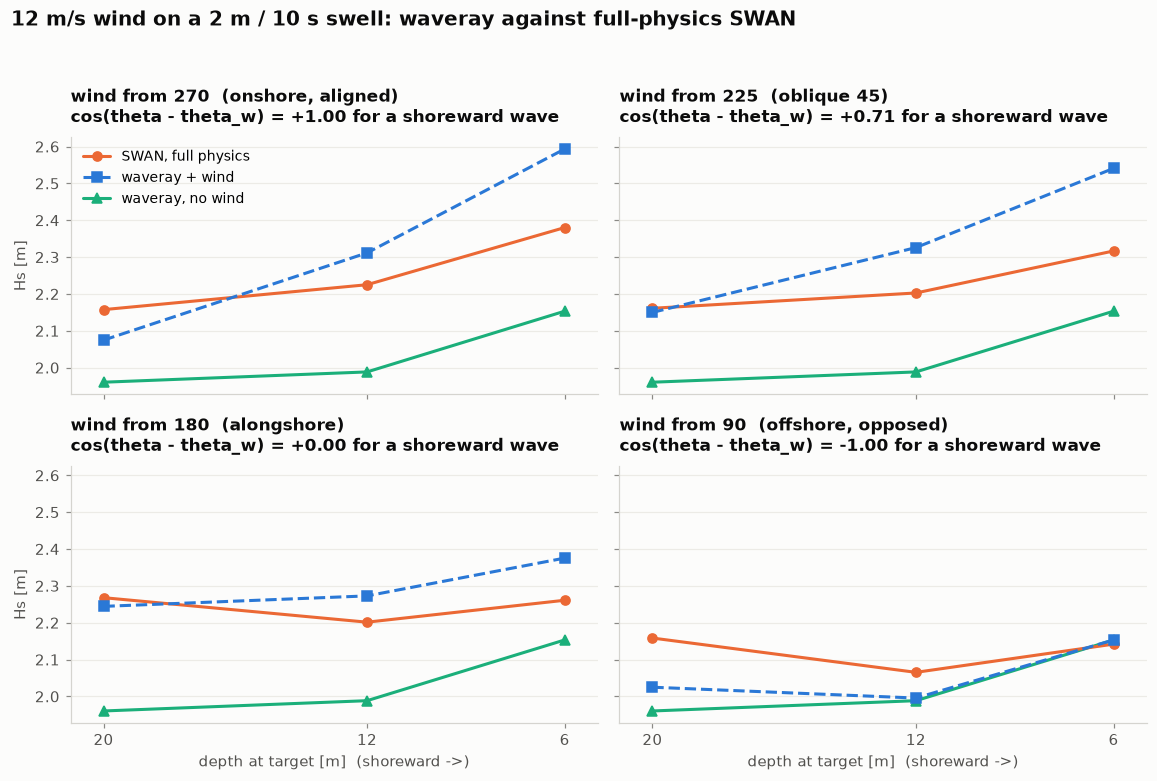

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10.6, 7.2), sharex=True, sharey=True)
for ax, (wd, label) in zip(axes.ravel(), WIND_DIRS, strict=True):
    r = runs[wd]
    ax.grid(axis="y", zorder=0)
    ax.plot(
        TARGET_DEPTHS,
        r["swan"]["HSIGN"],
        "o-",
        color=COLOR_SWAN,
        zorder=3,
        label="SWAN, full physics",
    )
    ax.plot(TARGET_DEPTHS, r["wr_hs"], "s--", color=COLOR_WRAY, zorder=4, label="waveray + wind")
    ax.plot(TARGET_DEPTHS, ref_hs, "^-", color=COLOR_NOWIND, zorder=2, label="waveray, no wind")
    cos = np.cos(np.deg2rad(wd - 270.0))
    ax.set_title(
        f"wind from {wd:.0f}  ({label})\ncos(theta - theta_w) = {cos:+.2f} for a shoreward wave"
    )
# sharex means one call sets all four; inverting per-axes would cancel out
axes[0, 0].set_xlim(21.0, 5.0)  # deep on the left, shoreward to the right
axes[0, 0].set_xticks(TARGET_DEPTHS)
for ax in axes[1]:
    ax.set_xlabel("depth at target [m]  (shoreward ->)")
for ax in axes[:, 0]:
    ax.set_ylabel("Hs [m]")
axes[0, 0].legend(loc="upper left", fontsize=9)
fig.suptitle(
    "12 m/s wind on a 2 m / 10 s swell: waveray against full-physics SWAN",
    x=0.012,
    ha="left",
    fontsize=13,
    fontweight="700",
    color=INK,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

In [5]:
rows = []
for wd, label in WIND_DIRS:
    r = runs[wd]
    for i, d in enumerate(TARGET_DEPTHS):
        rows.append(
            {
                "wind from": f"{wd:.0f} ({label})",
                "depth [m]": d,
                "SWAN Hs [m]": r["swan"]["HSIGN"][i],
                "waveray Hs [m]": r["wr_hs"][i],
                "no-wind Hs [m]": ref_hs[i],
                "waveray/SWAN": r["wr_hs"][i] / r["swan"]["HSIGN"][i],
                "wind adds (x)": r["wr_hs"][i] / ref_hs[i],
            }
        )
summary = pd.DataFrame(rows)
display(summary.round(3))

print("waveray/SWAN by direction:")
for wd, label in WIND_DIRS:
    sub = summary[summary["wind from"].str.startswith(f"{wd:.0f} ")]["waveray/SWAN"]
    print(f"  {wd:>3.0f} {label:<18} {sub.min():.3f} - {sub.max():.3f}")
print("\nwind contribution (waveray with wind / waveray no wind):")
for wd, label in WIND_DIRS:
    sub = summary[summary["wind from"].str.startswith(f"{wd:.0f} ")]["wind adds (x)"]
    print(f"  {wd:>3.0f} {label:<18} {sub.min():.3f} - {sub.max():.3f}")

,wind from,depth [m],SWAN Hs [m],waveray Hs [m],no-wind Hs [m],waveray/SWAN,wind adds (x)
0,"270 (onshore, aligned)",20.0,2.157,2.075,1.960,0.962,1.058
1,"270 (onshore, aligned)",12.0,2.225,2.311,1.988,1.039,1.163
2,"270 (onshore, aligned)",6.0,2.380,2.593,2.153,1.090,1.204
3,225 (oblique 45),20.0,2.161,2.150,1.960,0.995,1.097
4,225 (oblique 45),12.0,2.203,2.326,1.988,1.056,1.170
5,225 (oblique 45),6.0,2.317,2.541,2.153,1.097,1.180
6,180 (alongshore),20.0,2.268,2.244,1.960,0.990,1.145
7,180 (alongshore),12.0,2.201,2.273,1.988,1.032,1.143
8,180 (alongshore),6.0,2.261,2.375,2.153,1.051,1.103
9,"90 (offshore, opposed)",20.0,2.158,2.025,1.960,0.938,1.033


waveray/SWAN by direction:
  270 onshore, aligned   0.962 - 1.090
  225 oblique 45         0.995 - 1.097
  180 alongshore         0.990 - 1.051
   90 offshore, opposed  0.938 - 1.005

wind contribution (waveray with wind / waveray no wind):
  270 onshore, aligned   1.058 - 1.204
  225 oblique 45         1.097 - 1.180
  180 alongshore         1.103 - 1.145
   90 offshore, opposed  1.000 - 1.033


Two things are visible in every panel.

**waveray crosses SWAN as the water shallows.** At the 20 m target it sits 0.5–6 %
*below* SWAN in all four directions; by the 6 m target it is 0.5–10 % *above*. The
operator's wind increment keeps growing with fetch because nothing dissipates it,
while SWAN's is already limited by whitecapping — so the surrogate error changes
sign along the profile instead of being a constant bias. A single calibration
factor cannot remove it.

**The opposed case barely moves at all.** At 90° the wind adds ×1.00–1.03 to
waveray's no-wind answer, against ×1.06–1.20 onshore. That is the
$\max[0,\cos]$ cutoff: a shoreward-running wave gets no growth from a seaward
wind, so there is almost nothing to add. SWAN, which does build a sea in that
wind, sits above waveray at both deeper targets.

But $H_s$ cannot say *where* either model put the energy, and that is the question the
directional cutoff actually answers. The spectra below can.

## The spectra at the location of interest

Everything below is at the **12 m target**, 10.4 km inshore of the boundary.

Each row is one wind direction, and the columns are the wind-free waveray reference
(identical in every row — it is the common baseline), SWAN, and waveray with the wind.
All six panels share one logarithmic colour scale over three decades, so a panel that
looks emptier really is.

Directions are nautical *coming-from*, north at the top, clockwise. Note the two models'
directional bins are staggered half a bin — SWAN centres on 5°, 15°, … and waveray on
0°, 10°, … — so each panel is drawn on its own bin edges rather than a shared grid.

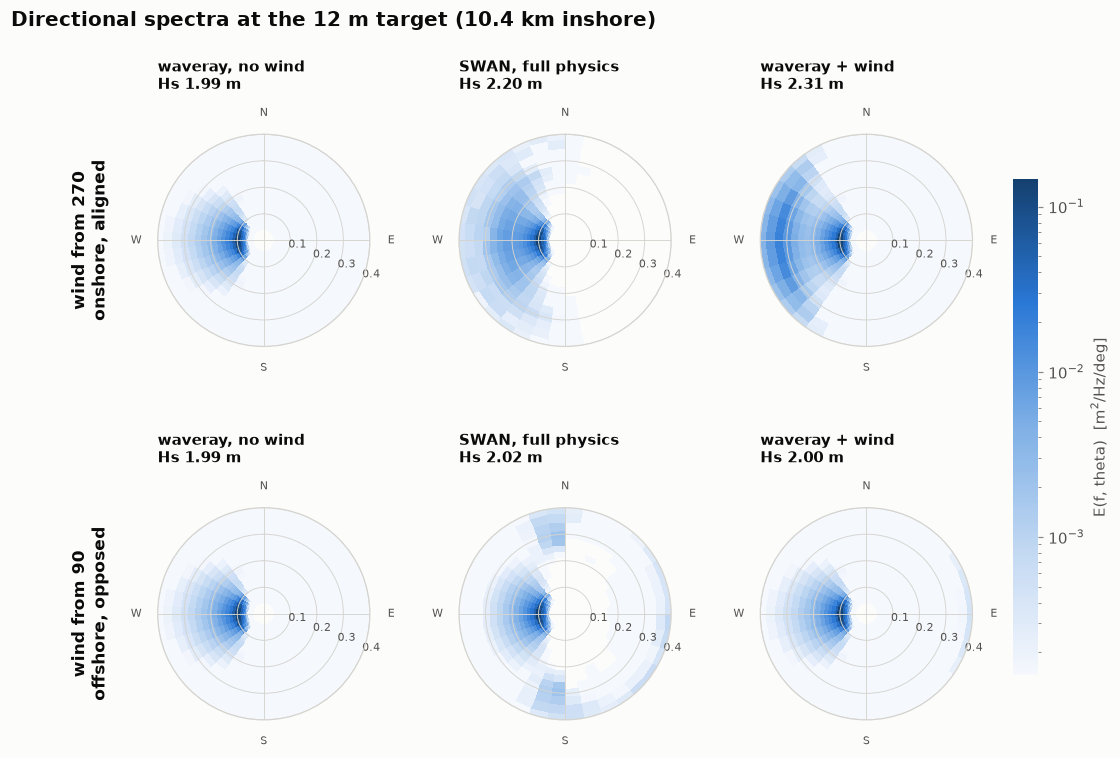

In [6]:
def polar_spec(ax, freqs, dirs, efth, norm):
    """Directional spectrum on polar axes, nautical coming-from, N at top."""
    freqs, dirs, efth = np.asarray(freqs), np.asarray(dirs), np.asarray(efth)
    ddir = dirs[1] - dirs[0]
    theta_e = np.deg2rad(np.r_[dirs, dirs[-1] + ddir] - ddir / 2)
    freq_e = np.r_[freqs[0], np.sqrt(freqs[1:] * freqs[:-1]), freqs[-1]]
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    m = ax.pcolormesh(theta_e, freq_e, efth, cmap=CMAP_SPEC, norm=norm, shading="flat")
    ax.set_rmax(0.4)
    ax.set_rticks([0.1, 0.2, 0.3, 0.4])
    ax.set_rlabel_position(112)
    ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    ax.set_xticklabels(["N", "E", "S", "W"], fontsize=8)
    ax.tick_params(labelsize=7.5)
    ax.grid(color="#d5d4cf", lw=0.6)
    return m


show = [(270.0, "onshore, aligned"), (90.0, "offshore, opposed")]
panels = []
for wd, _label in show:
    r = runs[wd]
    panels.append(
        [
            ("waveray, no wind", case_ref.freqs, case_ref.dirs, ref_spec[FOCUS]),
            (
                "SWAN, full physics",
                r["swan_spec"].freq.values,
                r["swan_spec"].dir.values,
                swan_efth(r["swan_spec"], r["case"].targets[FOCUS]).values,
            ),
            ("waveray + wind", r["case"].freqs, r["case"].dirs, r["wr_spec"][FOCUS]),
        ]
    )

vmax = max(np.max(p[3]) for row in panels for p in row)
norm = LogNorm(vmin=vmax / 1e3, vmax=vmax)

fig, axes = plt.subplots(
    len(show),
    3,
    figsize=(11.8, 7.8),
    subplot_kw={"projection": "polar"},
    gridspec_kw={"wspace": 0.42, "hspace": 0.30},
)
for i, ((wd, label), row) in enumerate(zip(show, panels, strict=True)):
    for j, (title, f, d, e) in enumerate(row):
        m = polar_spec(axes[i, j], f, d, e, norm)
        axes[i, j].set_title(f"{title}\nHs {hs_of(e, f, d):.2f} m", fontsize=9.5, pad=12)
    axes[i, 0].text(
        -0.32,
        0.5,
        f"wind from {wd:.0f}\n{label}",
        transform=axes[i, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=11,
        fontweight="700",
        color=INK,
    )
cb = fig.colorbar(m, ax=axes, pad=0.04, shrink=0.75)
cb.set_label("E(f, theta)  [m$^2$/Hz/deg]", color=INK_2)
cb.outline.set_visible(False)
fig.suptitle(
    f"Directional spectra at the 12 m target ({targets[FOCUS, 0] / 1e3:.1f} km inshore)",
    x=0.012,
    ha="left",
    fontsize=13,
    fontweight="700",
    color=INK,
)
plt.show()

The onshore row is the agreeable case. The wind-free reference is a narrow swell lobe
from the west; both SWAN and waveray broaden it and fill in the higher frequencies on
the same side, and the totals land within a few per cent (2.20 m against 2.31 m).

The offshore row is where the two models genuinely part company. A wind *from* 90°
blows toward the west, so the sea it raises travels offshore, and in coming-from
convention that energy belongs in the **eastern half** of the plot — the half the
swell leaves empty. SWAN has it: a diffuse high-frequency fill across the east,
strongest either side of due east where refraction over the slope has turned it.
waveray's panel is indistinguishable from the wind-free reference beside it. Every
ray that reaches this target from seaward is running into the wind, so
$\cos(\theta-\theta_w) < 0$ and the Komen cutoff zeroes its growth.

Both totals are near 2.0 m, which is the trap: the heights agree to about 1 % while one
model has an entire wind sea the other does not.

### Where in frequency the difference sits

Collapsing the direction axis, $E(f) = \int E(f,\theta)\,\mathrm{d}\theta$, separates the
swell peak (which both models propagate, and which should agree) from the wind sea
(which only one of them generates properly).

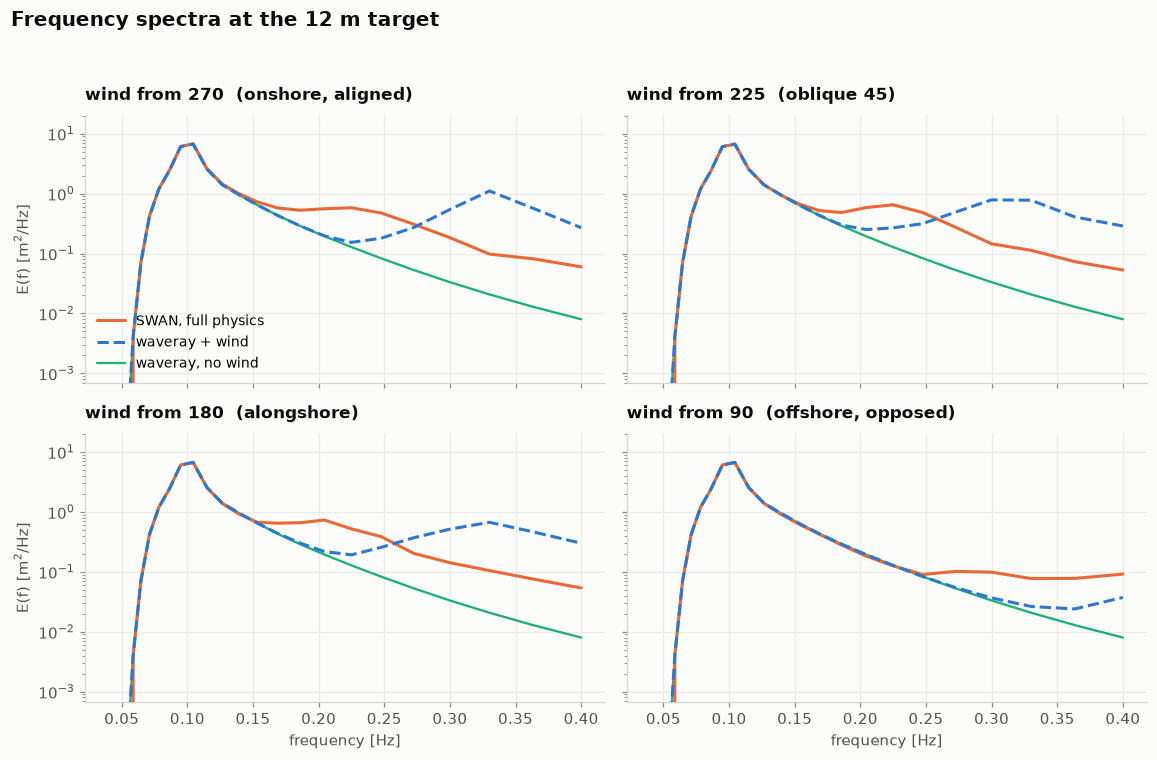

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10.6, 7.0), sharex=True, sharey=True)
ref_ef = ref_spec[FOCUS].sum(axis=1) * (case_ref.dirs[1] - case_ref.dirs[0])
ef_peak = 0.0

for ax, (wd, label) in zip(axes.ravel(), WIND_DIRS, strict=True):
    r = runs[wd]
    ds = r["swan_spec"]
    sw_e = swan_efth(ds, r["case"].targets[FOCUS]).values
    sw_dirs = ds.dir.values
    sw_ef = sw_e.sum(axis=1) * float(sw_dirs[1] - sw_dirs[0])
    wr_ef = r["wr_spec"][FOCUS].sum(axis=1) * (r["case"].dirs[1] - r["case"].dirs[0])

    ax.grid(zorder=0)
    ax.plot(ds.freq.values, sw_ef, "-", color=COLOR_SWAN, zorder=3, label="SWAN, full physics")
    ax.plot(r["case"].freqs, wr_ef, "--", color=COLOR_WRAY, zorder=4, label="waveray + wind")
    ax.plot(
        case_ref.freqs, ref_ef, "-", color=COLOR_NOWIND, lw=1.5, zorder=2, label="waveray, no wind"
    )
    ax.set_yscale("log")
    ax.set_title(f"wind from {wd:.0f}  ({label})")
    ef_peak = max(ef_peak, sw_ef.max(), wr_ef.max())
# the JONSWAP low-frequency cutoff runs to ~1e-18 and would own the axis
axes[0, 0].set_ylim(ef_peak / 1e4, ef_peak * 3)
for ax in axes[1]:
    ax.set_xlabel("frequency [Hz]")
for ax in axes[:, 0]:
    ax.set_ylabel("E(f) [m$^2$/Hz]")
axes[0, 0].legend(loc="lower left", fontsize=9)
fig.suptitle(
    "Frequency spectra at the 12 m target",
    x=0.012,
    ha="left",
    fontsize=13,
    fontweight="700",
    color=INK,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### The wind sea is in the wrong band

Both models put the swell peak at 0.10 Hz and agree to the line out to about 0.15 Hz,
so propagation is not what separates them. Above that they diverge in a specific and
repeatable way: **SWAN's wind sea shows up as a shoulder near 0.20 Hz, waveray's as a
bump near 0.30 Hz.**

That offset is the missing quadruplet interactions. Wind input is strongest at high
frequency, so a young sea is *born* near the tail; in a full spectral model the
nonlinear four-wave transfer then moves that energy down-frequency, which is what
makes a wind sea's peak period lengthen as it develops. waveray has the input term
and no transfer, so its sea stays where it was generated and piles up there — which
is also why it needs the saturation closure to stay bounded at all.

This is the sharpest statement of what the surrogate costs: integrated $H_s$ can agree
to a few per cent while the spectrum is wrong in a way that matters. If you need a
period or a spectral shape out of the downscale rather than a height, read it with
that in mind.

The opposed panel is the exception, and it fails the other way — waveray's tail sits
*below* SWAN's across the whole wind-sea band, because there is no lobe there to
misplace.

### Two quantitative checks

First, that the spectra and the height profiles are the same field: $H_s$ recomputed
from SWAN's 2D output must reproduce SWAN's own table (to within the precision of
SWAN's integer-scaled ASCII spectral format), and waveray's must reproduce the heights
plotted above. Second, the fraction of energy above 0.18 Hz — a number for the wind sea
the polar panels show.

In [8]:
WIND_BAND = 0.18  # Hz; above this is wind sea, below is the 0.1 Hz swell peak


def band_frac(e, f, d, hi):
    """Fraction of m0 above ``hi`` Hz."""
    e, f = np.asarray(e), np.asarray(f)
    tot = spectral_moment(e[None], f, d, n=0)[0]
    sel = f > hi
    sub = spectral_moment(e[sel][None], f[sel], d, n=0)[0]
    return sub / tot if tot > 0 else np.nan


rows = []
for wd, label in WIND_DIRS:
    r = runs[wd]
    ds = r["swan_spec"]
    sw_e = swan_efth(ds, r["case"].targets[FOCUS]).values
    sw_f, sw_d = ds.freq.values, ds.dir.values
    wr_e, wr_f, wr_d = r["wr_spec"][FOCUS], r["case"].freqs, r["case"].dirs
    rows.append(
        {
            "wind from": f"{wd:.0f} ({label})",
            "SWAN Hs, table [m]": r["swan"]["HSIGN"][FOCUS],
            "SWAN Hs, from spec [m]": hs_of(sw_e, sw_f, sw_d),
            "waveray Hs [m]": hs_of(wr_e, wr_f, wr_d),
            f"SWAN E(f>{WIND_BAND}) frac": band_frac(sw_e, sw_f, sw_d, WIND_BAND),
            f"waveray E(f>{WIND_BAND}) frac": band_frac(wr_e, wr_f, wr_d, WIND_BAND),
        }
    )
checks = pd.DataFrame(rows)
display(checks.round(4))

err = (checks["SWAN Hs, from spec [m]"] / checks["SWAN Hs, table [m]"] - 1).abs().max()
print(f"SWAN's 2D output reproduces its own table Hs to {err:.2%} (quadrature + file precision)")

ref_frac = band_frac(ref_spec[FOCUS], case_ref.freqs, case_ref.dirs, WIND_BAND)
print(f"the wind-free reference carries {ref_frac:.2%} of its energy above {WIND_BAND} Hz")

,wind from,"SWAN Hs, table [m]","SWAN Hs, from spec [m]",waveray Hs [m],SWAN E(f>0.18) frac,waveray E(f>0.18) frac
0,"270 (onshore, aligned)",2.2250,2.1992,2.3115,0.2190,0.3132
1,225 (oblique 45),2.2026,2.1795,2.3258,0.2206,0.3217
2,180 (alongshore),2.2014,2.1780,2.2728,0.2178,0.2890
3,"90 (offshore, opposed)",2.0653,2.0230,1.9955,0.1084,0.0785


SWAN's 2D output reproduces its own table Hs to 2.05% (quadrature + file precision)
the wind-free reference carries 7.19% of its energy above 0.18 Hz


## What this establishes

- **The directional cutoff is doing its job.** The wind contribution falls from
  ×1.06–1.20 aligned, through ×1.10–1.18 oblique and ×1.10–1.15 alongshore, to
  ×1.00–1.03 opposed. That is $\max[0,\cos(\theta-\theta_w)]$ visible as directional
  behaviour rather than as a fitted height.
- **On integrated height, all four directions sit within roughly 6 % of full-physics
  SWAN at the 20 m and 12 m targets**, with the saturation closure on. That is the
  useful envelope for a downscale.
- **The error changes sign shoreward**, from 0.5–6 % under at 20 m to 0.5–10 % over at
  6 m, because waveray's wind increment grows with fetch and has no sink. No single
  scaling constant removes that.
- **The spectra are wrong in a way the heights hide.** waveray's wind sea sits near
  0.30 Hz where SWAN's sits near 0.20 Hz — the down-frequency quadruplet transfer is
  the one term that would move it, and a frequency-diagonal operator cannot carry it.
  Trust the height ahead of the period here.
- **An opposing wind is the worst case, and it is structural.** SWAN builds an
  offshore-going wind sea over the fetch and counts it at the target; a backward-ray
  operator seeded only along rays that reach the target cannot, because those rays all
  run into the wind. At the 12 m target that is 10.8 % of SWAN's energy above 0.18 Hz
  against waveray's 7.9 %, on a wind-free baseline of 7.2 % — waveray adds almost
  nothing where SWAN adds a lobe. Retuning the closure cannot fix it: no ceiling on a
  wind increment adds energy that was never generated. Worth knowing before trusting a
  site under a land breeze.
- **The offshore case is also the least reproducible in SWAN.** Repeat runs of this
  configuration moved 6–9 % at the 20 m target against 3–4 % elsewhere, which is why
  `test_wind_direction_on_swell` gives it the loosest bounds of the four. A wind
  opposing the swell makes the nonlinear solve harder, not easier.

Measured waveray/SWAN across three runs of each case — the *asserted* bounds in
`tests/test_validation_swan.py` are deliberately looser, because SWAN's own run-to-run
spread is a large part of this spread:

```
offshore    0.88 - 1.01     alongshore  0.99 - 1.06
oblique     0.97 - 1.10     onshore     0.95 - 1.09
```